
# SPSDS Assignment — Demand Forecasting Analysis
Author : May Zin Ko <br>
Dataset: Historical_Product_Demand.csv (Kaggle, Felix Zhao 2017) <br>
Models : ARIMA, SARIMA, Random Forest, XGBoost, Prophet <br>
Tracks : (1) Per Warehouse  (2) Top 5 Highest-Demand Products <br>
Metrics: MAE, RMSE, MAPE <br>
============================================================================= <br>

## Section 1 - Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf

 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from pmdarima import auto_arima
from prophet import Prophet

2026-06-25 13:27:22.970277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Importing plotly failed. Interactive plots will not work.


## Section 2 - Load Raw Data

In [4]:
df = pd.read_csv('Historical_Product_Demand.csv')
print("RAW DATA LOADED")
print(f"  Shape   : {df.shape}")
print(f"  Columns : {df.columns.tolist()}")
print(f"  Dtypes  :")
print(df.dtypes.to_string())
print(f"\n  Missing values per column:")
print(df.isnull().sum().to_string())

RAW DATA LOADED
  Shape   : (1048575, 5)
  Columns : ['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand']
  Dtypes  :
Product_Code        object
Warehouse           object
Product_Category    object
Date                object
Order_Demand        object

  Missing values per column:
Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0


## Section 3 - Data Preprocessing

 ### --- Step 1: Remove rows with missing Date ---

In [5]:
df_cleaned = df.copy()
missing_dates = df_cleaned['Date'].isnull().sum()
df_cleaned = df_cleaned.dropna(subset=['Date'])
print(f"\nStep 1 — Remove missing Date rows")
print(f"  Rows removed : {missing_dates:,}")
print(f"  Rows remaining : {len(df_cleaned):,}")


Step 1 — Remove missing Date rows
  Rows removed : 11,239
  Rows remaining : 1,037,336


### --- Step 2: Remove parenthesis entries in Order_Demand ---

In [6]:
bracket_mask = df_cleaned['Order_Demand'].astype(str).str.contains(
    r'\(', regex=True
)
bracket_count = bracket_mask.sum()
df_cleaned = df_cleaned[~bracket_mask]
print(f"\nStep 2 — Remove parenthesis (cancellation) entries in Order_Demand")
print(f"  Rows removed : {bracket_count:,}")
print(f"  Rows remaining : {len(df_cleaned):,}")


Step 2 — Remove parenthesis (cancellation) entries in Order_Demand
  Rows removed : 5,899
  Rows remaining : 1,031,437


### --- Step 3: Fix data types ---

In [7]:
df_cleaned['Date']         = pd.to_datetime(df_cleaned['Date'])
df_cleaned['Order_Demand'] = pd.to_numeric(df_cleaned['Order_Demand'],
                                            errors='coerce')
df_cleaned = df_cleaned.dropna(subset=['Order_Demand'])
print(f"\nStep 3 — Convert data types")
print(f"  Date         : object → datetime")
print(f"  Order_Demand : object → numeric")
print(f"  Rows remaining : {len(df_cleaned):,}")


Step 3 — Convert data types
  Date         : object → datetime
  Order_Demand : object → numeric
  Rows remaining : 1,031,437


 ### --- Step 4: Remove extreme duplicates (appearing 5+ times) ---

In [8]:
dup_counts = df_cleaned.groupby(
    df_cleaned.columns.tolist()
).size().reset_index(name='count')
 
patterns_5plus = dup_counts[dup_counts['count'] >= 5]
total_5plus_rows = patterns_5plus['count'].sum()
rows_to_remove   = (patterns_5plus['count'] - 1).sum()
 
print(f"\nStep 4 — Remove extreme duplicates (≥5 identical rows)")
print(f"  Distinct patterns appearing ≥5 times : {len(patterns_5plus):,}")
print(f"  Total rows in those patterns         : {total_5plus_rows:,}")
print(f"  Rows to remove (keep 1 per pattern)  : {rows_to_remove:,}")
 
patterns_to_trim = patterns_5plus.drop(columns='count')
df_high = df_cleaned.merge(
    patterns_to_trim, how='inner'
).drop_duplicates(keep='first')
df_low  = df_cleaned.merge(
    patterns_to_trim, how='left', indicator=True
)
df_low  = df_low[df_low['_merge'] == 'left_only'].drop(columns='_merge')
df_cleaned = pd.concat([df_high, df_low]).reset_index(drop=True)
 
# Verify
remaining_5plus = df_cleaned.groupby(
    df_cleaned.columns.tolist()
).size().reset_index(name='count')
verify = (remaining_5plus['count'] >= 5).sum()
print(f"  Rows remaining after removal  : {len(df_cleaned):,}")
print(f"  Verification — patterns ≥5 remaining : {verify} (should be 0)")


Step 4 — Remove extreme duplicates (≥5 identical rows)
  Distinct patterns appearing ≥5 times : 2,071
  Total rows in those patterns         : 14,547
  Rows to remove (keep 1 per pattern)  : 12,476
  Rows remaining after removal  : 1,018,961
  Verification — patterns ≥5 remaining : 0 (should be 0)


### --- Preprocessing summary ---

In [9]:
print(f"  PREPROCESSING COMPLETE")
print(f"  Raw rows    : {len(df):,}")
print(f"  Clean rows  : {len(df_cleaned):,}")
print(f"  Rows removed: {len(df) - len(df_cleaned):,}")

  PREPROCESSING COMPLETE
  Raw rows    : 1,048,575
  Clean rows  : 1,018,961
  Rows removed: 29,614


In [10]:
# Save cleaned dataset
df_cleaned.to_csv('demand_cleaned.csv', index=False)
print(f"  Cleaned data saved to: demand_cleaned.csv")

  Cleaned data saved to: demand_cleaned.csv


## Section 4 - Monthly Aggregation

In [11]:
df_cleaned['YearMonth'] = df_cleaned['Date'].dt.to_period('M')
# --- Warehouse-level monthly series ---
warehouse_monthly = (
    df_cleaned.groupby(['Warehouse', 'YearMonth'])['Order_Demand']
    .sum()
    .reset_index()
    .sort_values(['Warehouse', 'YearMonth'])
)
warehouse_monthly['Date'] = warehouse_monthly['YearMonth'].dt.to_timestamp()
 
# --- Top 5 highest-demand products ---
top5_codes = (
    df_cleaned.groupby('Product_Code')['Order_Demand']
    .sum()
    .nlargest(5)
    .index.tolist()
)
 
print("\n" + "=" * 60)
print("  MONTHLY AGGREGATION")
print("=" * 60)
print(f"\nWarehouses and monthly data points:")
for wh in sorted(df_cleaned['Warehouse'].unique()):
    n = len(warehouse_monthly[warehouse_monthly['Warehouse'] == wh])
    print(f"  {wh}: {n} monthly observations")
 
print(f"\nTop 5 Highest-Demand Products:")
for code in top5_codes:
    total = df_cleaned[df_cleaned['Product_Code'] == code]['Order_Demand'].sum()
    print(f"  {code}: {total:,.0f} units total demand")
 
product_monthly = (
    df_cleaned[df_cleaned['Product_Code'].isin(top5_codes)]
    .groupby(['Product_Code', 'YearMonth'])['Order_Demand']
    .sum()
    .reset_index()
    .sort_values(['Product_Code', 'YearMonth'])
)
product_monthly['Date'] = product_monthly['YearMonth'].dt.to_timestamp()


  MONTHLY AGGREGATION

Warehouses and monthly data points:
  Whse_A: 64 monthly observations
  Whse_C: 65 monthly observations
  Whse_J: 63 monthly observations
  Whse_S: 63 monthly observations

Top 5 Highest-Demand Products:
  Product_1359: 467,081,000 units total demand
  Product_1248: 289,006,000 units total demand
  Product_0083: 210,539,000 units total demand
  Product_1341: 169,777,000 units total demand
  Product_1295: 119,093,500 units total demand


## Section 5 - Evaluation Matrics

In [12]:
def compute_metrics(actual, predicted):
    """Return MAE, RMSE, MAPE for actual vs predicted arrays."""
    actual    = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    return round(mae, 2), round(rmse, 2), round(mape, 2)

## Section 6 - Train / Test Split

In [13]:
# (80% train, 20% test — time-ordered)
def train_test_split_ts(series):
    n     = len(series)
    split = int(n * 0.8)
    return series.iloc[:split], series.iloc[split:]

## Section 7 - Lag Feature Engineering  (Random Forest and XGBoost)

In [14]:
def make_lag_features(series, lags=[1, 2, 3, 6, 12]):
    """
    Transform a univariate series into a supervised learning DataFrame.
    Lag columns contain demand values from N months prior.
    Rows with NaN are dropped.
    """
    df_lags = pd.DataFrame({'y': series.values})
    for lag in lags:
        df_lags[f'lag_{lag}'] = df_lags['y'].shift(lag)
    df_lags = df_lags.dropna().reset_index(drop=True)
    X = df_lags.drop(columns='y')
    y = df_lags['y']
    return X, y

## Section 8 - Model Functions

In [15]:

# --- 8.1 ARIMA ---
def run_arima(train, test):
    try:
        model    = auto_arima(
            train, seasonal=False,
            information_criterion='aic',
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore'
        )
        forecast = model.predict(n_periods=len(test))
        forecast = np.maximum(forecast, 0)
        mae, rmse, mape = compute_metrics(test, forecast)
        return forecast, mae, rmse, mape
    except Exception as e:
        print(f"    ARIMA error: {e}")
        return None, None, None, None
 
# --- 8.2 SARIMA ---
def run_sarima(train, test):
    try:
        model    = auto_arima(
            train, seasonal=True, m=12,
            information_criterion='aic',
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore'
        )
        forecast = model.predict(n_periods=len(test))
        forecast = np.maximum(forecast, 0)
        mae, rmse, mape = compute_metrics(test, forecast)
        return forecast, mae, rmse, mape
    except Exception as e:
        print(f"    SARIMA error: {e}")
        return None, None, None, None
 
# --- 8.3 Random Forest ---
def run_random_forest(train, test, lags=[1, 2, 3, 6, 12]):
    try:
        full_series   = pd.concat([train, test], ignore_index=True)
        X_all, y_all  = make_lag_features(full_series, lags)
        n_train_lagged = len(train) - max(lags)
        if n_train_lagged <= 0:
            print("    RF: not enough data after lag creation")
            return None, None, None, None
        X_train = X_all.iloc[:n_train_lagged]
        y_train = y_all.iloc[:n_train_lagged]
        X_test  = X_all.iloc[n_train_lagged:]
        y_test  = y_all.iloc[n_train_lagged:]
        model   = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        forecast = np.maximum(model.predict(X_test), 0)
        mae, rmse, mape = compute_metrics(y_test, forecast)
        return forecast, mae, rmse, mape
    except Exception as e:
        print(f"    Random Forest error: {e}")
        return None, None, None, None
 
# --- 8.4 XGBoost ---
def run_xgboost(train, test, lags=[1, 2, 3, 6, 12]):
    try:
        full_series   = pd.concat([train, test], ignore_index=True)
        X_all, y_all  = make_lag_features(full_series, lags)
        n_train_lagged = len(train) - max(lags)
        if n_train_lagged <= 0:
            print("    XGBoost: not enough data after lag creation")
            return None, None, None, None
        X_train = X_all.iloc[:n_train_lagged]
        y_train = y_all.iloc[:n_train_lagged]
        X_test  = X_all.iloc[n_train_lagged:]
        y_test  = y_all.iloc[n_train_lagged:]
        model   = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        forecast = np.maximum(model.predict(X_test), 0)
        mae, rmse, mape = compute_metrics(y_test, forecast)
        return forecast, mae, rmse, mape
    except Exception as e:
        print(f"    XGBoost error: {e}")
        return None, None, None, None
 
# --- 8.5 Prophet ---
def run_prophet(train, test, train_dates, test_dates):
    try:
        prophet_train = pd.DataFrame({
            'ds': train_dates.values,
            'y':  train.values
        })
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95
        )
        model.fit(prophet_train)
        future       = pd.DataFrame({'ds': test_dates.values})
        forecast_df  = model.predict(future)
        forecast     = np.maximum(forecast_df['yhat'].values, 0)
        mae, rmse, mape = compute_metrics(test, forecast)
        return forecast, mae, rmse, mape
    except Exception as e:
        print(f"    Prophet error: {e}")
        return None, None, None, None


# --- 8.6 LSTM ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

def run_lstm(train, test, lags=[1, 2, 3, 6, 12]):
    try:
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
        test_scaled  = scaler.transform(test.values.reshape(-1, 1)).flatten()

        full_scaled = np.concatenate([train_scaled, test_scaled])
        lag = max(lags)  # use 12 as lookback window

        X_all, y_all = [], []
        for i in range(lag, len(full_scaled)):
            X_all.append(full_scaled[i-lag:i])
            y_all.append(full_scaled[i])
        X_all = np.array(X_all)
        y_all = np.array(y_all)

        n_train = len(train_scaled) - lag
        X_train, y_train = X_all[:n_train], y_all[:n_train]
        X_test,  y_test  = X_all[n_train:], y_all[n_train:]

        # Reshape for LSTM: (samples, timesteps, features)
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

        model = Sequential([
            LSTM(32, input_shape=(lag, 1)),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        model.fit(X_train, y_train,
                  epochs=100, batch_size=8, verbose=0,
                  callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])

        forecast_scaled = model.predict(X_test, verbose=0).flatten()
        forecast = scaler.inverse_transform(forecast_scaled.reshape(-1,1)).flatten()
        forecast = np.maximum(forecast, 0)

        mae, rmse, mape = compute_metrics(test.values[-len(forecast):], forecast)
        return forecast, mae, rmse, mape
    except Exception as e:
        print(f"    LSTM error: {e}")
        return None, None, None, None

## Section 9 - Run All Models on a Single Series 

In [16]:
def run_all_models(series, dates, label):
    train_s, test_s = train_test_split_ts(series)
    train_d, test_d = train_test_split_ts(dates)
 
    print(f"\n  {label}")
    print(f"    Series : {len(series)} months  "
          f"(train={len(train_s)}, test={len(test_s)})")
 
    results = {}
    print("    Running ARIMA ...")
    results['ARIMA']         = run_arima(train_s.values, test_s.values)
    print("    Running SARIMA ...")
    results['SARIMA']        = run_sarima(train_s.values, test_s.values)
    print("    Running Random Forest ...")
    results['Random Forest'] = run_random_forest(train_s, test_s)
    print("    Running XGBoost ...")
    results['XGBoost']       = run_xgboost(train_s, test_s)
    print("    Running Prophet ...")
    results['Prophet']       = run_prophet(train_s, test_s, train_d, test_d)
    print("    Running LSTM ...")
    results['LSTM'] = run_lstm(train_s, test_s)
 
    return results, train_s, test_s, train_d, test_d


## Section 10 - Forecast Plot

In [21]:
def plot_forecasts(train_s, test_s, train_d, test_d,
                   model_results, label, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(train_d.values, train_s.values,
            color='grey', linewidth=1.2, label='Actual (train)', alpha=0.7)
    ax.plot(test_d.values, test_s.values,
            color='black', linewidth=2, label='Actual (test)')
 
    colours = {
        'ARIMA':         '#e41a1c',
        'SARIMA':        '#ff7f00',
        'Random Forest': '#4daf4a',
        'XGBoost':       '#377eb8',
        'Prophet':       '#984ea3',
        'LSTM'   :       '#00BFFF'
    }
    for model_name, (forecast, mae, rmse, mape) in model_results.items():
        if forecast is not None:
            n = min(len(forecast), len(test_d))
            ax.plot(
                test_d.values[:n], forecast[:n],
                color=colours.get(model_name, 'brown'),
                linewidth=1.5, linestyle='--',
                label=f"{model_name} (MAPE={mape:.1f}%)"
            )
 
    ax.set_title(f"Demand Forecast — {label}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Monthly Demand")
    ax.legend(loc='upper left', fontsize=8, framealpha=0.7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
 
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"    Plot saved: {save_path}")
    plt.show()
    plt.close()


## Section 11 - Results Table

In [22]:
def print_metrics_table(all_results, track_label):
    print(f"\n{'=' * 70}")
    print(f"  RESULTS — {track_label}")
    print(f"{'=' * 70}")
    print(f"{'Series':<20} {'Model':<16} {'MAE':>12} {'RMSE':>12} {'MAPE (%)':>10}")
    print("-" * 72)
    for series_name, model_results in all_results.items():
        for model_name, (_, mae, rmse, mape) in model_results.items():
            if mae is not None:
                print(f"{series_name:<20} {model_name:<16} "
                      f"{mae:>12,.1f} {rmse:>12,.1f} {mape:>10.2f}%")
    print("=" * 70)

## Section 12 - (Output) Diagnostic Analysis
ADF Stationarity Tests, ACF/PACF Plots, ARIMA Order Selection

  DIAGNOSTIC ANALYSIS — WAREHOUSES
  ADF Test — Whse_A
    ADF Statistic : -3.8468
    p-value       : 0.0025
    Stationary    : Yes (p < 0.05)



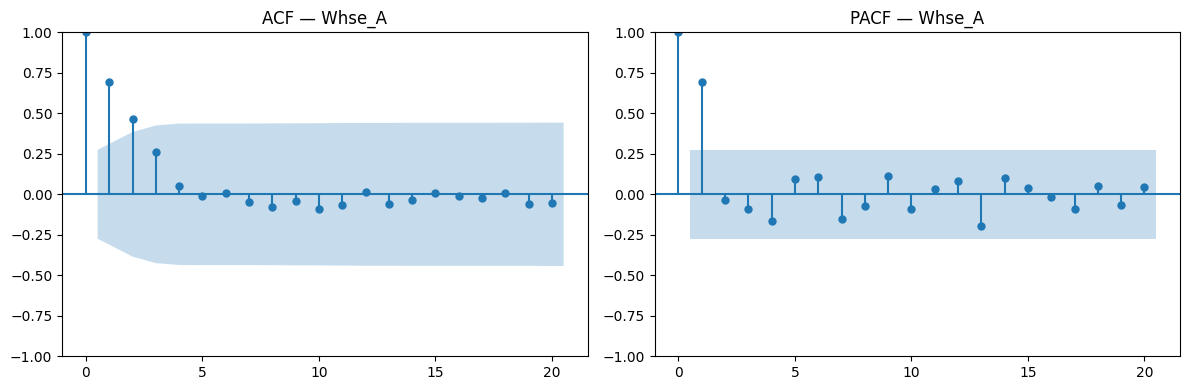

  Whse_A — ARIMA order  : (1, 0, 0)   AIC: 1472.54
  Whse_A — SARIMA order : (1, 0, 0) x (0, 0, 0, 0)   AIC: 1469.17

  ADF Test — Whse_C
    ADF Statistic : -4.0596
    p-value       : 0.0011
    Stationary    : Yes (p < 0.05)



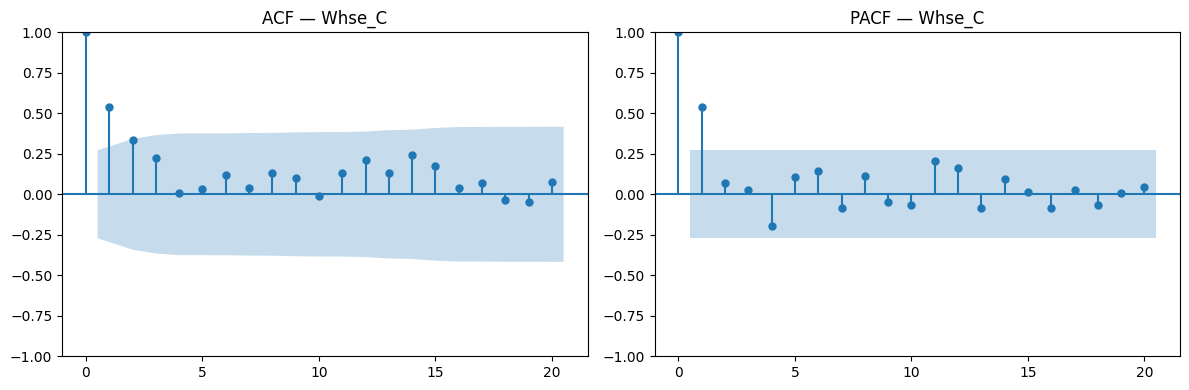

  Whse_C — ARIMA order  : (0, 1, 1)   AIC: 1656.4
  Whse_C — SARIMA order : (0, 1, 1) x (0, 0, 0, 0)   AIC: 1656.4

  ADF Test — Whse_J
    ADF Statistic : -4.6170
    p-value       : 0.0001
    Stationary    : Yes (p < 0.05)



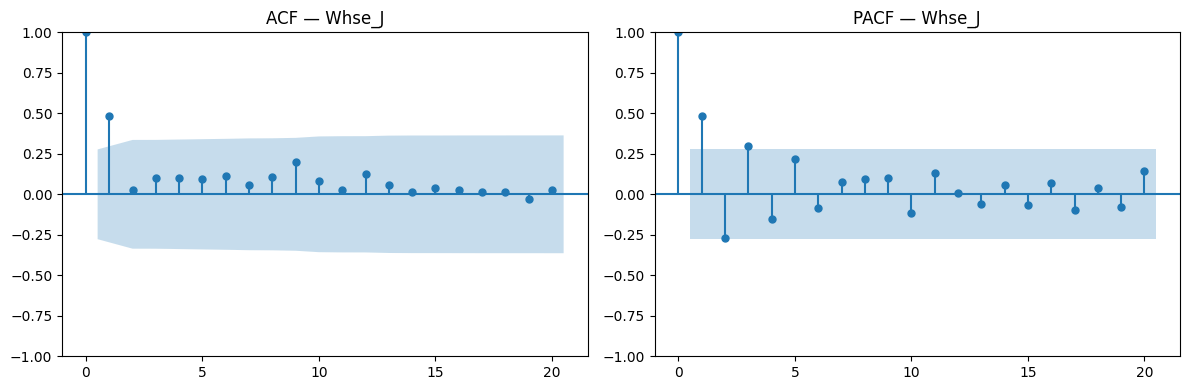

  Whse_J — ARIMA order  : (0, 1, 0)   AIC: 1719.18
  Whse_J — SARIMA order : (0, 1, 0) x (0, 0, 0, 0)   AIC: 1716.66

  ADF Test — Whse_S
    ADF Statistic : -3.8015
    p-value       : 0.0029
    Stationary    : Yes (p < 0.05)



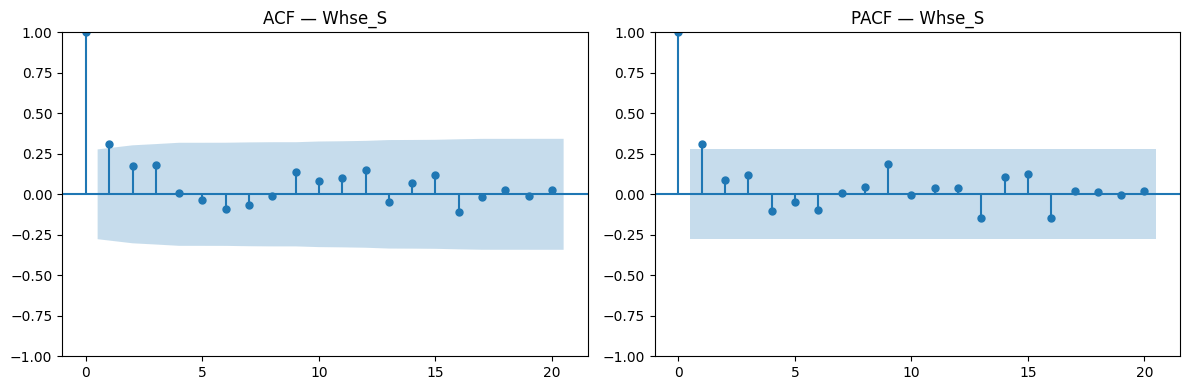

  Whse_S — ARIMA order  : (1, 1, 0)   AIC: 1640.1
  Whse_S — SARIMA order : (1, 1, 0) x (0, 0, 0, 0)   AIC: 1640.1

  DIAGNOSTIC ANALYSIS — TOP 5 PRODUCTS
  ADF Test — Product_1359
    ADF Statistic : -7.4868
    p-value       : 0.0000
    Stationary    : Yes (p < 0.05)



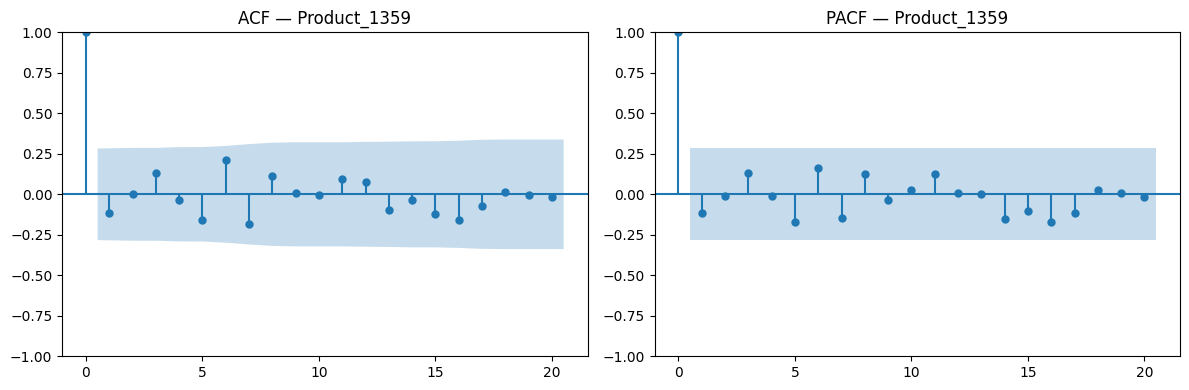

  Product_1359 — ARIMA order  : (0, 0, 0)   AIC: 1469.31
  Product_1359 — SARIMA order : (0, 0, 0) x (0, 0, 0, 0)   AIC: 1469.31

  ADF Test — Product_1248
    ADF Statistic : -1.3034
    p-value       : 0.6276
    Stationary    : No (p < 0.05)



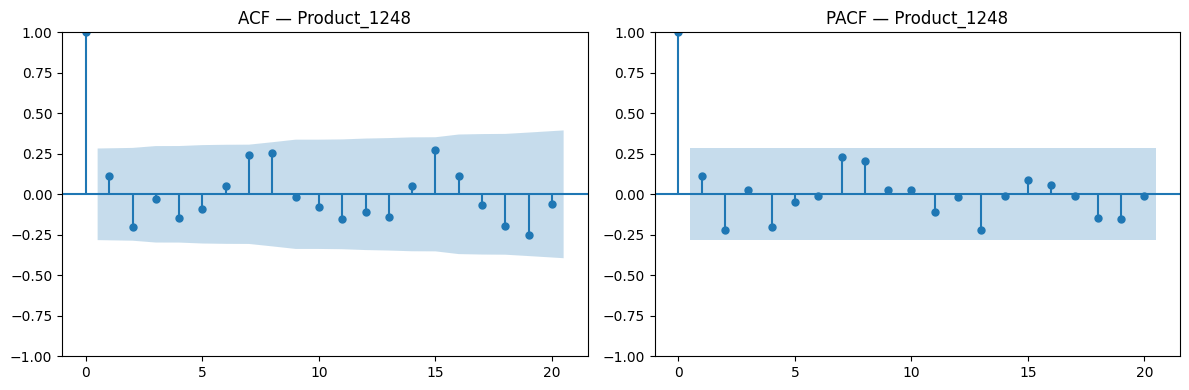

  Product_1248 — ARIMA order  : (0, 0, 2)   AIC: 1499.43
  Product_1248 — SARIMA order : (0, 0, 2) x (0, 0, 0, 0)   AIC: 1499.67

  ADF Test — Product_0083
    ADF Statistic : -5.9536
    p-value       : 0.0000
    Stationary    : Yes (p < 0.05)



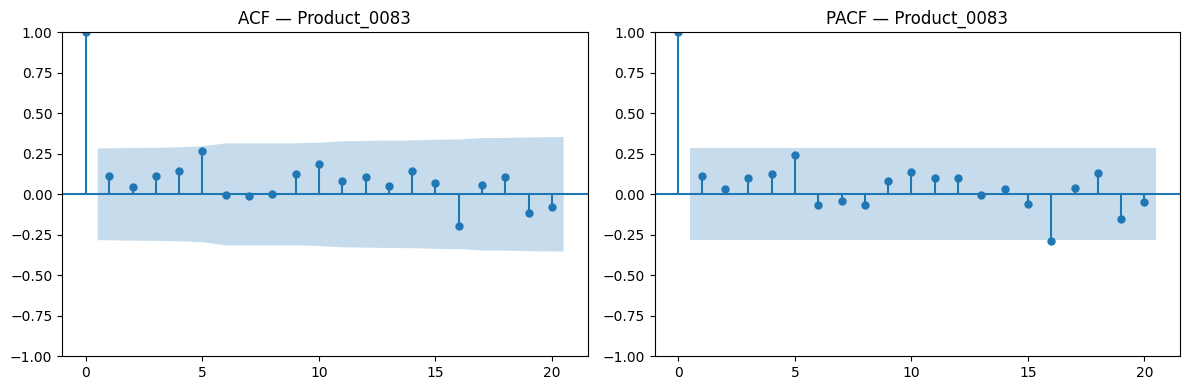

  Product_0083 — ARIMA order  : (2, 1, 2)   AIC: 1431.33
  Product_0083 — SARIMA order : (2, 1, 2) x (0, 0, 0, 0)   AIC: 1431.33

  ADF Test — Product_1341
    ADF Statistic : -6.1916
    p-value       : 0.0000
    Stationary    : Yes (p < 0.05)



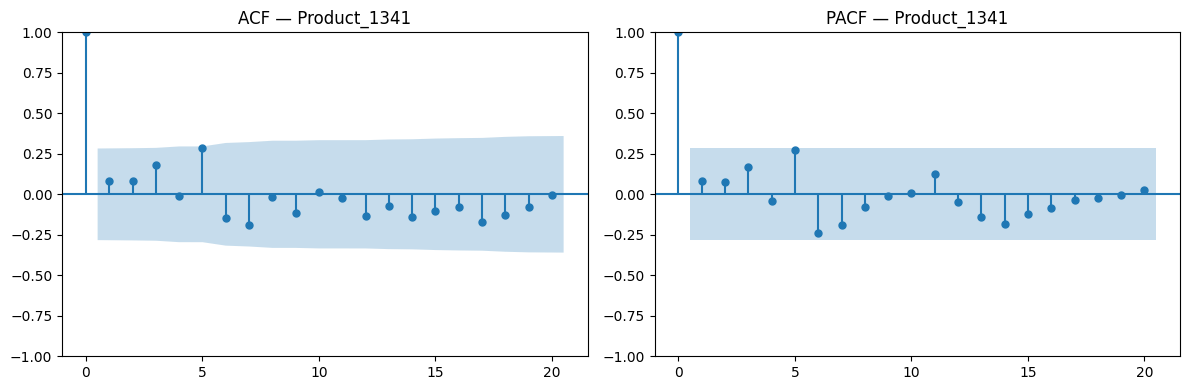

  Product_1341 — ARIMA order  : (0, 0, 0)   AIC: 1477.53
  Product_1341 — SARIMA order : (0, 0, 0) x (0, 0, 0, 0)   AIC: 1477.53

  ADF Test — Product_1295
    ADF Statistic : -4.3851
    p-value       : 0.0003
    Stationary    : Yes (p < 0.05)



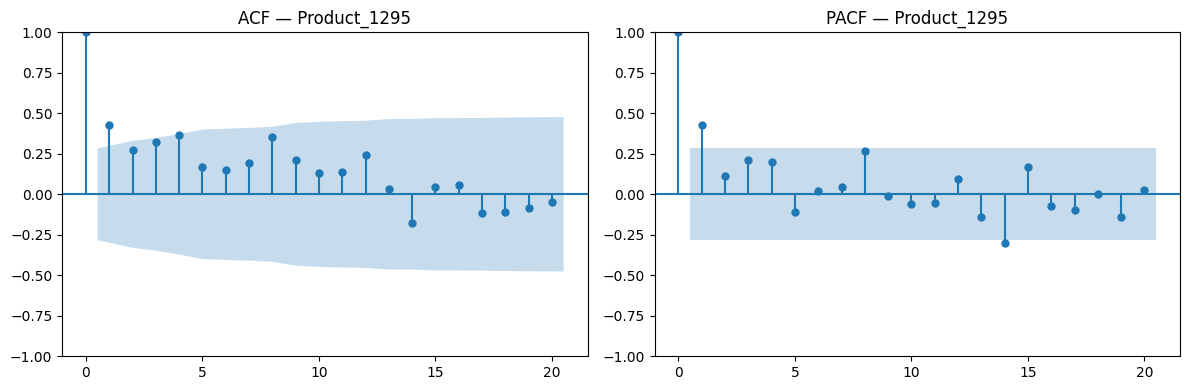

  Product_1295 — ARIMA order  : (2, 1, 2)   AIC: 1337.68
  Product_1295 — SARIMA order : (2, 1, 2) x (0, 0, 0, 0)   AIC: 1339.78



In [23]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"  ADF Test — {label}")
    print(f"    ADF Statistic : {result[0]:.4f}")
    print(f"    p-value       : {result[1]:.4f}")
    print(f"    Stationary    : {'Yes' if result[1] < 0.05 else 'No'} (p < 0.05)")
    print()

def plot_acf_pacf(series, label):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series.dropna(),  lags=20, ax=axes[0], title=f"ACF — {label}")
    plot_pacf(series.dropna(), lags=20, ax=axes[1], title=f"PACF — {label}")
    plt.tight_layout()
    plt.savefig(f"acf_pacf_{label.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def get_arima_order(train, seasonal=False):
    model = auto_arima(
        train, seasonal=seasonal, m=12 if seasonal else 1,
        information_criterion='aic', stepwise=True,
        suppress_warnings=True, error_action='ignore'
    )
    return model.order, model.seasonal_order, round(model.aic(), 2)

print("=" * 60)
print("  DIAGNOSTIC ANALYSIS — WAREHOUSES")
print("=" * 60)

for wh in sorted(df_cleaned['Warehouse'].unique()):
    wh_data = warehouse_monthly[warehouse_monthly['Warehouse'] == wh]
    series  = wh_data['Order_Demand'].reset_index(drop=True)
    train_s, _ = train_test_split_ts(series)
    
    # ADF test
    run_adf(train_s, wh)
    
    # ACF / PACF
    plot_acf_pacf(train_s, wh)
    
    # ARIMA order and AIC
    order, s_order, aic_arima  = get_arima_order(train_s, seasonal=False)
    _, _, aic_sarima            = get_arima_order(train_s, seasonal=True)
    print(f"  {wh} — ARIMA order  : {order}   AIC: {aic_arima}")
    print(f"  {wh} — SARIMA order : {order} x {s_order}   AIC: {aic_sarima}")
    print()

print("=" * 60)
print("  DIAGNOSTIC ANALYSIS — TOP 5 PRODUCTS")
print("=" * 60)

for prod in top5_codes:
    prod_data = product_monthly[product_monthly['Product_Code'] == prod]
    series    = prod_data['Order_Demand'].reset_index(drop=True)
    train_s, _ = train_test_split_ts(series)
    
    # ADF test
    run_adf(train_s, prod)
    
    # ACF / PACF
    plot_acf_pacf(train_s, prod)
    
    # ARIMA order and AIC
    order, s_order, aic_arima  = get_arima_order(train_s, seasonal=False)
    _, _, aic_sarima            = get_arima_order(train_s, seasonal=True)
    print(f"  {prod} — ARIMA order  : {order}   AIC: {aic_arima}")
    print(f"  {prod} — SARIMA order : {order} x {s_order}   AIC: {aic_sarima}")
    print()

## Section 13 - (Output) Track 1: Per Warehouse


  TRACK 1 — WAREHOUSE-LEVEL ANALYSIS

  Whse_A
    Series : 64 months  (train=51, test=13)
    Running ARIMA ...
    Running SARIMA ...


13:37:18 - cmdstanpy - INFO - Chain [1] start processing


    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


13:37:19 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


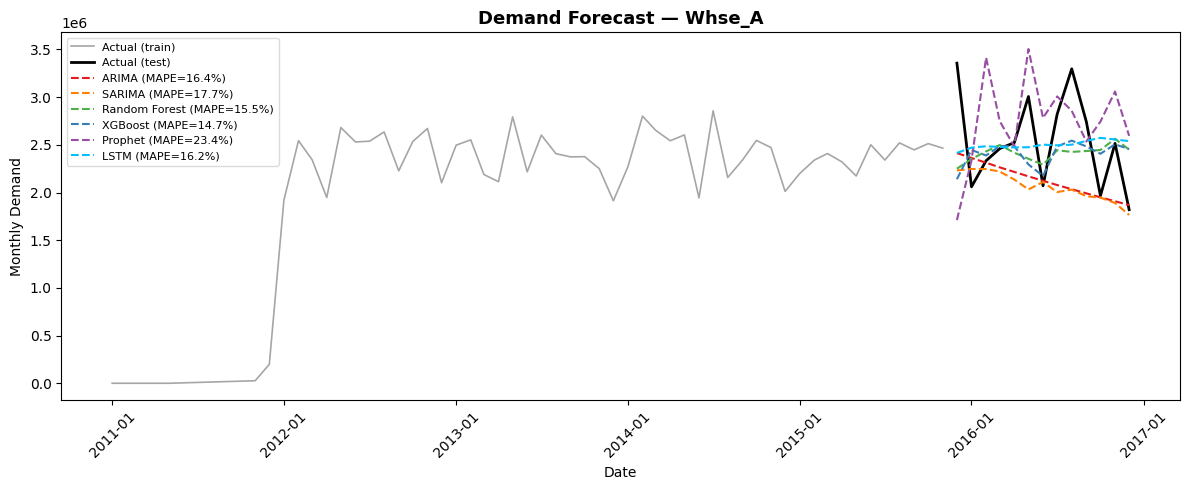


  Whse_C
    Series : 65 months  (train=52, test=13)
    Running ARIMA ...
    Running SARIMA ...


13:37:27 - cmdstanpy - INFO - Chain [1] start processing


    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


13:37:28 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


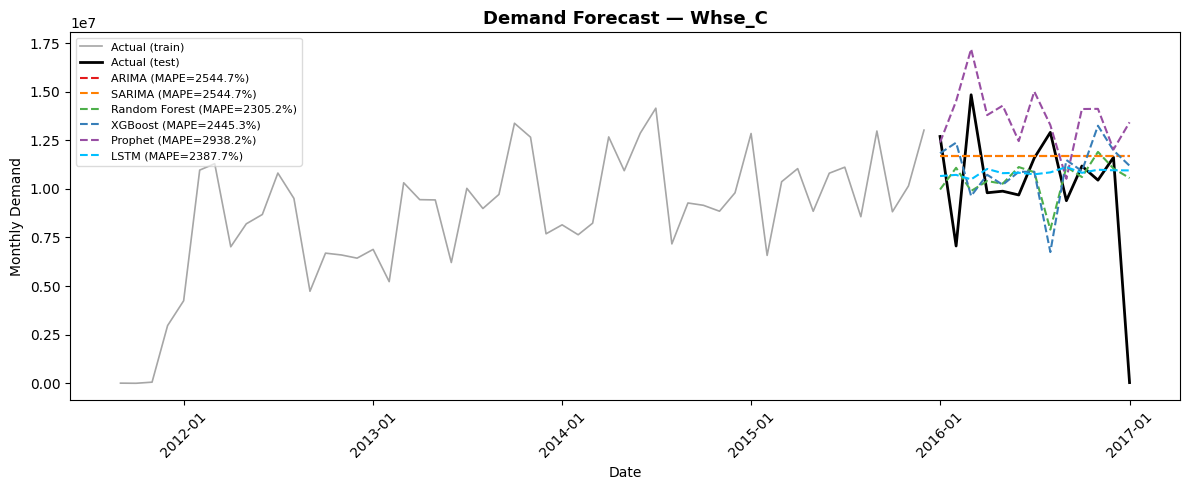


  Whse_J
    Series : 63 months  (train=50, test=13)
    Running ARIMA ...
    Running SARIMA ...
    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


13:37:35 - cmdstanpy - INFO - Chain [1] start processing
13:37:36 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


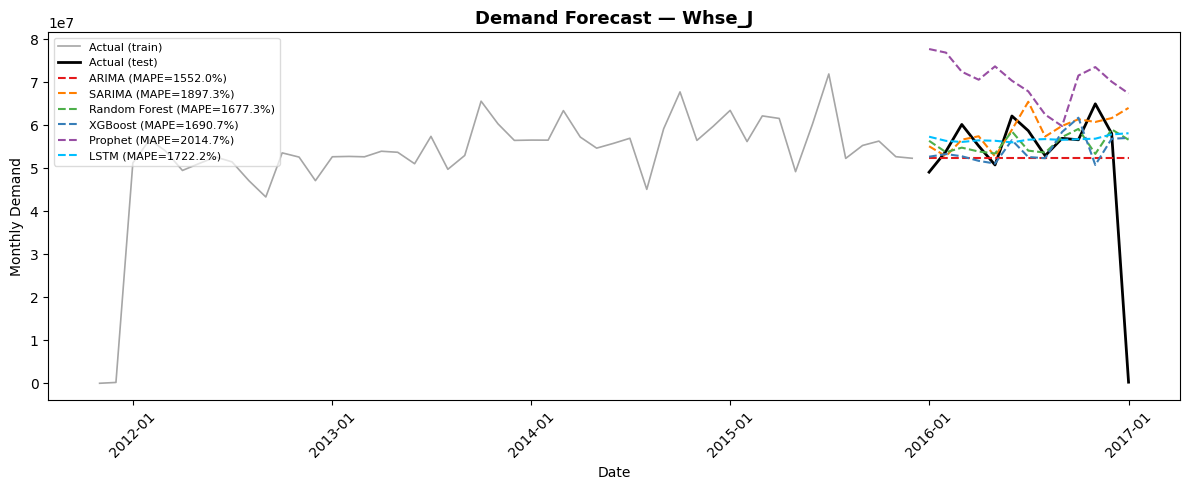


  Whse_S
    Series : 63 months  (train=50, test=13)
    Running ARIMA ...
    Running SARIMA ...
    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


13:37:44 - cmdstanpy - INFO - Chain [1] start processing
13:37:44 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


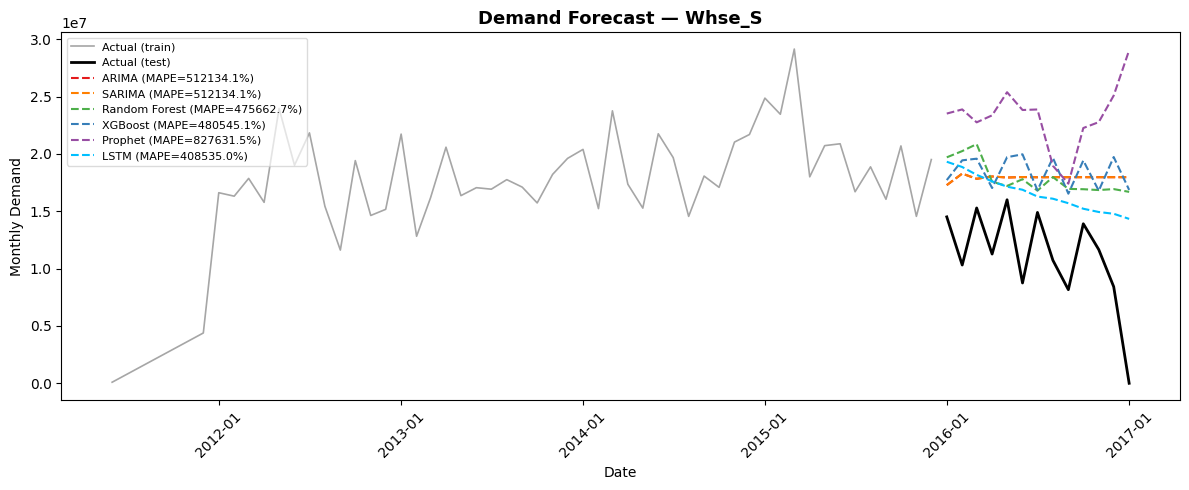


  RESULTS — TRACK 1 — WAREHOUSE
Series               Model                     MAE         RMSE   MAPE (%)
------------------------------------------------------------------------
Whse_A               ARIMA               468,207.2    613,735.7      16.45%
Whse_A               SARIMA              507,956.7    664,461.5      17.73%
Whse_A               Random Forest       402,205.9    513,856.8      15.50%
Whse_A               XGBoost             382,523.7    518,707.3      14.66%
Whse_A               Prophet             574,682.6    710,451.3      23.41%
Whse_A               LSTM                401,793.4    497,301.1      16.21%
Whse_C               ARIMA             2,416,760.2  3,789,254.0    2544.71%
Whse_C               SARIMA            2,416,760.2  3,789,254.0    2544.71%
Whse_C               Random Forest     2,670,353.2  3,850,903.9    2305.20%
Whse_C               XGBoost           2,874,323.8  4,241,092.8    2445.26%
Whse_C               Prophet           3,584,585.9  4,952,3

In [24]:
print("\n" + "=" * 60)
print("  TRACK 1 — WAREHOUSE-LEVEL ANALYSIS")
print("=" * 60)
 
warehouse_results = {}
for wh in sorted(df_cleaned['Warehouse'].unique()):
    wh_data = warehouse_monthly[warehouse_monthly['Warehouse'] == wh].copy()
    series  = wh_data['Order_Demand'].reset_index(drop=True)
    dates   = wh_data['Date'].reset_index(drop=True)
    results, train_s, test_s, train_d, test_d = run_all_models(
        series, dates, label=wh
    )
    warehouse_results[wh] = results
    plot_forecasts(
        train_s, test_s, train_d, test_d,
        results, label=wh
    )
 
print_metrics_table(warehouse_results, "TRACK 1 — WAREHOUSE")

## Section 14 - (Output) Track 2: Top 5 Highest Demand Products


  TRACK 2 — TOP 5 PRODUCT-LEVEL ANALYSIS

  Product_1359
    Series : 61 months  (train=48, test=13)
    Running ARIMA ...
    Running SARIMA ...


15:03:03 - cmdstanpy - INFO - Chain [1] start processing


    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


15:03:03 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


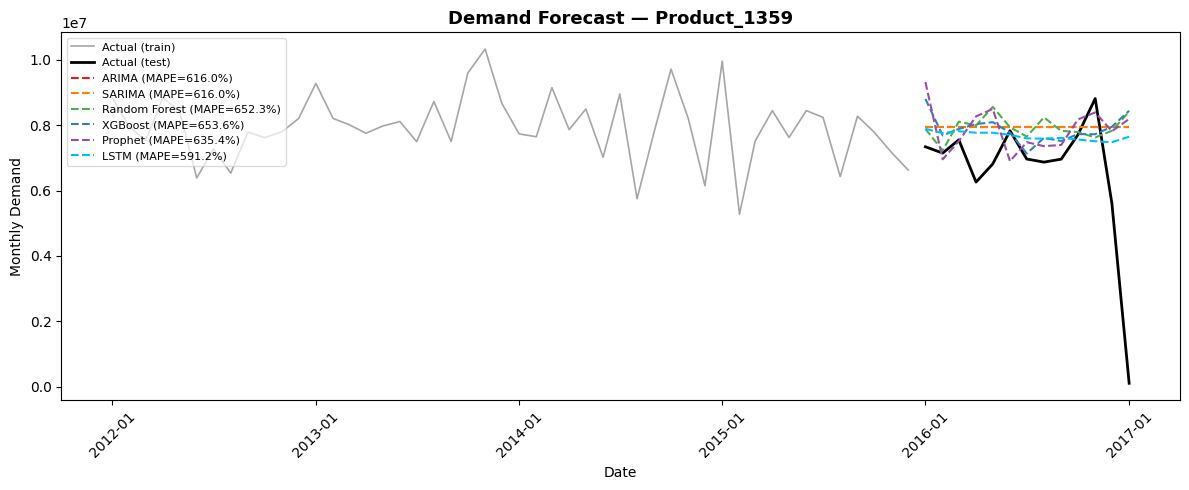


  Product_1248
    Series : 60 months  (train=48, test=12)
    Running ARIMA ...
    Running SARIMA ...


15:03:12 - cmdstanpy - INFO - Chain [1] start processing


    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


15:03:12 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


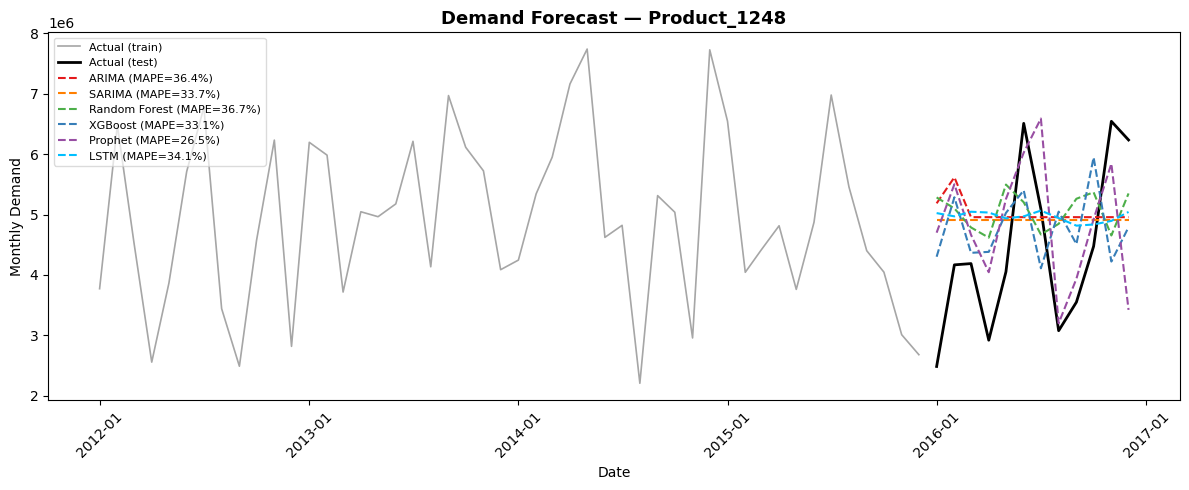


  Product_0083
    Series : 60 months  (train=48, test=12)
    Running ARIMA ...
    Running SARIMA ...


15:03:23 - cmdstanpy - INFO - Chain [1] start processing


    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


15:03:23 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


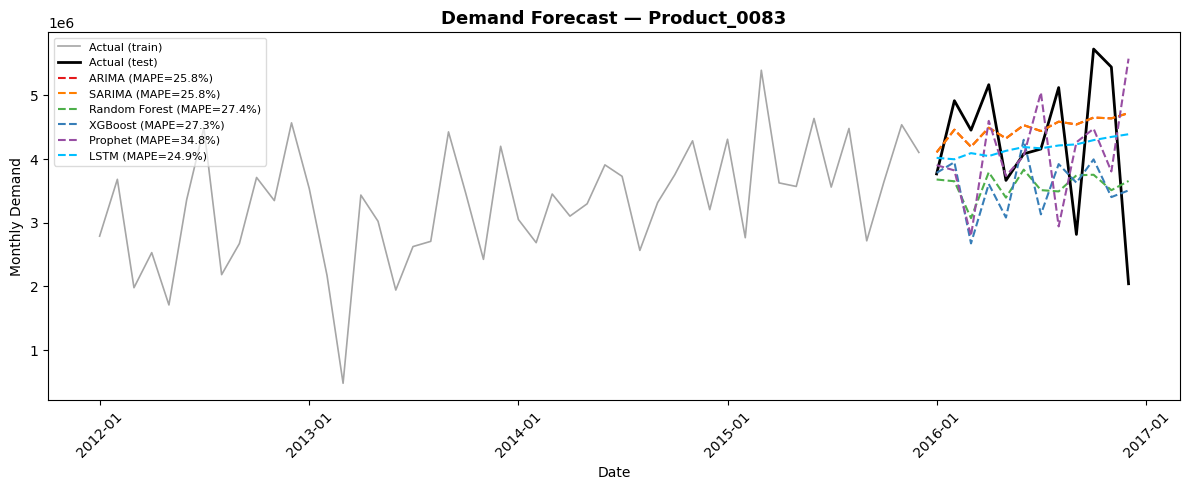


  Product_1341
    Series : 61 months  (train=48, test=13)
    Running ARIMA ...
    Running SARIMA ...
    Running Random Forest ...
    Running XGBoost ...
    Running Prophet ...


15:03:32 - cmdstanpy - INFO - Chain [1] start processing
15:03:32 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


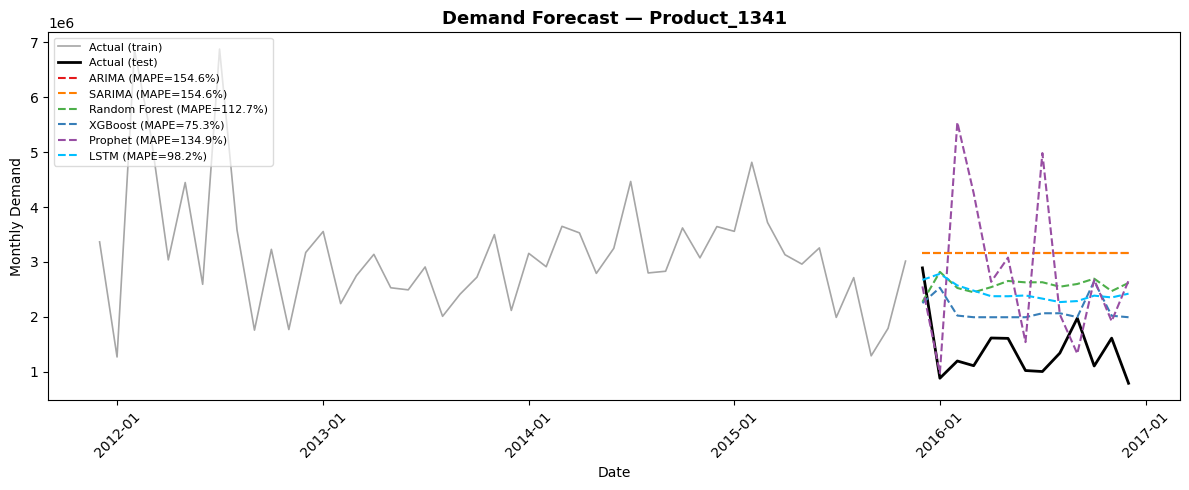


  Product_1295
    Series : 60 months  (train=48, test=12)
    Running ARIMA ...
    Running SARIMA ...
    Running Random Forest ...
    Running XGBoost ...


15:03:44 - cmdstanpy - INFO - Chain [1] start processing


    Running Prophet ...


15:03:45 - cmdstanpy - INFO - Chain [1] done processing


    Running LSTM ...


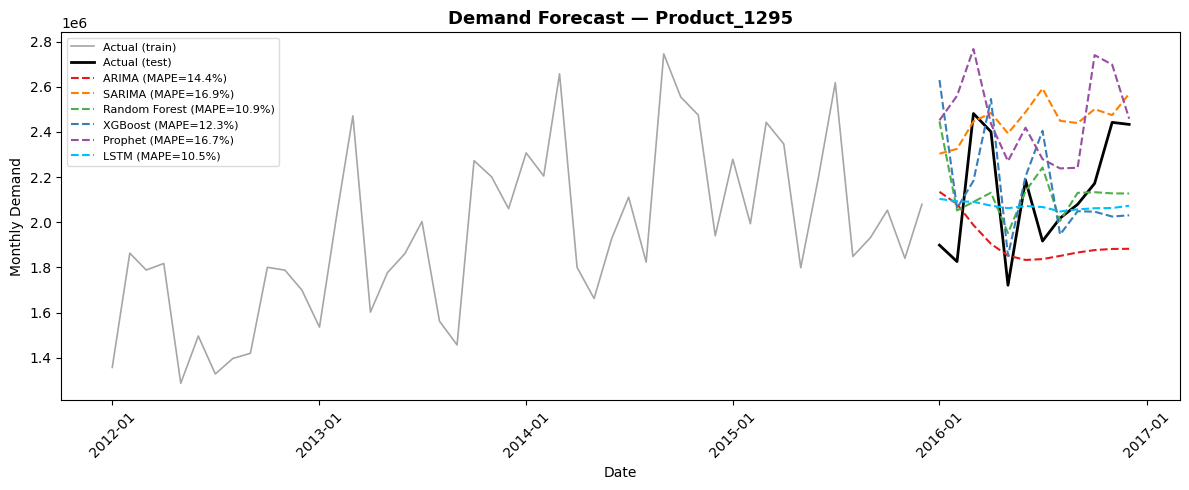


  RESULTS — TRACK 2 — TOP 5 PRODUCTS
Series               Model                     MAE         RMSE   MAPE (%)
------------------------------------------------------------------------
Product_1359         ARIMA             1,462,455.1  2,418,738.4     615.97%
Product_1359         SARIMA            1,462,455.1  2,418,738.4     615.97%
Product_1359         Random Forest     1,500,109.2  2,560,914.9     652.32%
Product_1359         XGBoost           1,439,523.3  2,549,593.1     653.62%
Product_1359         Prophet           1,497,329.2  2,528,710.2     635.38%
Product_1359         LSTM              1,299,550.5  2,278,624.1     591.19%
Product_1248         ARIMA             1,348,123.0  1,507,384.8      36.38%
Product_1248         SARIMA            1,258,826.4  1,416,143.1      33.67%
Product_1248         Random Forest     1,362,226.7  1,503,203.9      36.68%
Product_1248         XGBoost           1,317,224.0  1,423,169.1      33.10%
Product_1248         Prophet           1,067,510.0  1,

In [26]:
print("\n" + "=" * 60)
print("  TRACK 2 — TOP 5 PRODUCT-LEVEL ANALYSIS")
print("=" * 60)
 
product_results = {}
for prod in top5_codes:
    prod_data = product_monthly[product_monthly['Product_Code'] == prod].copy()
    series    = prod_data['Order_Demand'].reset_index(drop=True)
    dates     = prod_data['Date'].reset_index(drop=True)
    results, train_s, test_s, train_d, test_d = run_all_models(
        series, dates, label=prod
    )
    product_results[prod] = results
    plot_forecasts(
        train_s, test_s, train_d, test_d,
        results, label=prod
    )
 
print_metrics_table(product_results, "TRACK 2 — TOP 5 PRODUCTS")

## Section 15 - (Output) Results Summary

In [27]:
def build_summary_df(all_results, track_col_name):
    rows = []
    for name, model_results in all_results.items():
        for model, (_, mae, rmse, mape) in model_results.items():
            rows.append({
                track_col_name: name,
                'Model':        model,
                'MAE':          mae,
                'RMSE':         rmse,
                'MAPE (%)':     mape
            })
    return pd.DataFrame(rows)

wh_summary   = build_summary_df(warehouse_results, 'Warehouse')
prod_summary = build_summary_df(product_results,   'Product')

print("  WAREHOUSE RESULTS — ALL MODELS")
print("=" * 60)
print(wh_summary.to_string(index=False))

print("\n" + "=" * 60)
print("  PRODUCT RESULTS — ALL MODELS")
print("=" * 60)
print(prod_summary.to_string(index=False))

  WAREHOUSE RESULTS — ALL MODELS
Warehouse         Model         MAE        RMSE  MAPE (%)
   Whse_A         ARIMA   468207.25   613735.73     16.45
   Whse_A        SARIMA   507956.70   664461.50     17.73
   Whse_A Random Forest   402205.94   513856.84     15.50
   Whse_A       XGBoost   382523.73   518707.32     14.66
   Whse_A       Prophet   574682.62   710451.28     23.41
   Whse_A          LSTM   401793.37   497301.11     16.21
   Whse_C         ARIMA  2416760.20  3789254.04   2544.71
   Whse_C        SARIMA  2416760.20  3789254.04   2544.71
   Whse_C Random Forest  2670353.19  3850903.86   2305.20
   Whse_C       XGBoost  2874323.81  4241092.85   2445.26
   Whse_C       Prophet  3584585.94  4952302.16   2938.18
   Whse_C          LSTM  2340952.85  3595461.85   2387.67
   Whse_J         ARIMA  8718723.85 15604992.85   1551.95
   Whse_J        SARIMA  8346297.45 18103274.09   1897.26
   Whse_J Random Forest  7504360.07 16278158.21   1677.27
   Whse_J       XGBoost  8197288.08 166

## Section 16 - (Output) Best Model Per Series (by MAPE)

In [28]:
def print_best_model(summary_df, group_col):
    best = (
        summary_df.dropna(subset=['MAPE (%)'])
        .sort_values('MAPE (%)')
        .groupby(group_col)
        .first()
        .reset_index()[[group_col, 'Model', 'MAE', 'RMSE', 'MAPE (%)']]
    )
    print(best.to_string(index=False))

print("\n" + "=" * 60)
print("  BEST MODEL PER WAREHOUSE (lowest MAPE)")
print("=" * 60)
print_best_model(wh_summary, 'Warehouse')

print("\n" + "=" * 60)
print("  BEST MODEL PER PRODUCT (lowest MAPE)")
print("=" * 60)
print_best_model(prod_summary, 'Product')



  BEST MODEL PER WAREHOUSE (lowest MAPE)
Warehouse         Model        MAE        RMSE  MAPE (%)
   Whse_A       XGBoost  382523.73   518707.32     14.66
   Whse_C Random Forest 2670353.19  3850903.86   2305.20
   Whse_J         ARIMA 8718723.85 15604992.85   1551.95
   Whse_S          LSTM 5496037.23  6553803.84 408535.00

  BEST MODEL PER PRODUCT (lowest MAPE)
     Product   Model        MAE       RMSE  MAPE (%)
Product_0083    LSTM  869530.98 1084451.58     24.90
Product_1248 Prophet 1067509.96 1318860.24     26.53
Product_1295    LSTM  224859.10  260242.94     10.47
Product_1341 XGBoost  823042.07  939968.86     75.28
Product_1359    LSTM 1299550.54 2278624.07    591.19
